## PrISM Data Preprocessing notebook
### Step 0. Setup the paths and env variables

In [1]:
# =========================
# STEP 0 — Setup & contracts
# =========================
from pathlib import Path
import sys, re
import numpy as np
import pandas as pd
from tqdm import tqdm

ROOT = Path("/home/aidan/IMU_LM_Data")
sys.path.insert(0, str(ROOT))

from UTILS.helpers import _canon, load_contracts, to_continuous_stream, run_qa_checks, check_sample_integrity

C       = load_contracts(ROOT)
SCHEMA  = C["SCHEMA"]
RAW2ID  = C["RAW2ID"]
ID2NAME = C["ID2NAME"]
UNKNOWN_ID = C["UNKNOWN_ID"]
TARGET_HZ  = C["TARGET_HZ"]
CLEANED    = C["CLEANED"]

RAW       = ROOT / "data" / "raw_data" / "PrISM"
TASKS_DIR = RAW / "tasks"

print("RAW:", RAW)
print("TASKS_DIR:", TASKS_DIR)
print("TARGET_HZ:", TARGET_HZ)

RAW: /home/aidan/IMU_LM_Data/data/raw_data/PrISM
TASKS_DIR: /home/aidan/IMU_LM_Data/data/raw_data/PrISM/tasks
TARGET_HZ: 50


### Step 1. Ingest, preporccess and map the data 

In [2]:
# ============================
# STEP 1 — Load PRISM motion.txt + annotation.txt → per-segment dataframe
#   - Uses annotation.txt to assign procedural sub-task labels
#   - Drops BEGIN/END sentinel intervals
#   - Resamples each labeled segment to 50Hz independently
#   - Compound label format: {task_folder}_{annotation_step} (canonicalized)
# ============================
G_M_S2 = 9.80665
SKIP_STEPS_UPPER = {"BEGIN", "END"}

def list_tasks(tasks_dir: Path):
    return sorted([p.name for p in tasks_dir.iterdir() if p.is_dir()])

TASK_NAMES = list_tasks(TASKS_DIR)

KEEP_COLS = [
    "timestamp",
    "userAcceleration.x", "userAcceleration.y", "userAcceleration.z",
    "gravity.x", "gravity.y", "gravity.z",
    "rotationRate.x", "rotationRate.y", "rotationRate.z",
]

def read_motion_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", engine="python")
    missing = [c for c in KEEP_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"[PRISM] Missing columns in {path}: {missing}")
    return df[KEEP_COLS].copy()

def read_annotation_file(path: Path):
    """Return list of (timestamp_ms, step_label) sorted by timestamp."""
    ann = pd.read_csv(path)
    ann.columns = [c.strip() for c in ann.columns]
    ann = ann.sort_values("Timestamp").reset_index(drop=True)
    return list(zip(ann["Timestamp"].astype(float), ann["Step"].astype(str).str.strip()))

def parse_subject_trial(folder_name: str):
    # p10 / p2 / p1 ... (no dash → default session 1)
    m = re.match(r"^p(\d+)$", folder_name, flags=re.IGNORECASE)
    if m:
        return f"p{int(m.group(1))}", 1

    # P12-03 (participant 12, session 3)
    m = re.match(r"^P(\d+)-(\d+)$", folder_name)
    if m:
        return f"p{int(m.group(1))}", int(m.group(2))

    # latte_making numeric folders: 10, 11, ... (no dash → default session 1)
    m = re.match(r"^(\d+)$", folder_name)
    if m:
        return f"p{int(m.group(1))}", 1

    # latte_making authors: 1-authors, 2-authors, ... (default session 1)
    m = re.match(r"^(\d+)-authors$", folder_name, flags=re.IGNORECASE)
    if m:
        return f"auth{int(m.group(1))}", 1

    return None, None

def load_prism_native(tasks_dir: Path) -> pd.DataFrame:
    STEP_NS = int(1e9 // TARGET_HZ)  # 20_000_000 at 50Hz

    sessions = []
    task_seg_counts = {}
    task_row_counts = {}
    skipped_no_ann = 0
    skipped_unparsed = 0

    for task in tqdm(TASK_NAMES, desc="[PRISM] load tasks"):
        task_root = tasks_dir / task / "dataset" / "original"
        if not task_root.exists():
            continue

        for pdir in sorted([p for p in task_root.iterdir() if p.is_dir()], key=lambda x: x.name):
            motion_path = pdir / "motion.txt"
            ann_path = pdir / "annotation.txt"
            if not motion_path.exists():
                continue
            if not ann_path.exists():
                skipped_no_ann += 1
                continue

            subject_id, trial = parse_subject_trial(pdir.name)
            if subject_id is None:
                skipped_unparsed += 1
                continue

            # Read motion data
            mdf = read_motion_file(motion_path)
            if mdf.empty:
                continue

            # Raw timestamps in ms
            t_ms = mdf["timestamp"].to_numpy(np.float64)

            # Sensor values
            ax = (mdf["userAcceleration.x"].to_numpy(np.float64) + mdf["gravity.x"].to_numpy(np.float64)) * G_M_S2
            ay = (mdf["userAcceleration.y"].to_numpy(np.float64) + mdf["gravity.y"].to_numpy(np.float64)) * G_M_S2
            az = (mdf["userAcceleration.z"].to_numpy(np.float64) + mdf["gravity.z"].to_numpy(np.float64)) * G_M_S2
            gx = mdf["rotationRate.x"].to_numpy(np.float64)
            gy = mdf["rotationRate.y"].to_numpy(np.float64)
            gz = mdf["rotationRate.z"].to_numpy(np.float64)

            # Sort by timestamp
            order = np.argsort(t_ms)
            t_ms = t_ms[order]
            ax, ay, az = ax[order], ay[order], az[order]
            gx, gy, gz = gx[order], gy[order], gz[order]

            # Read annotations → build intervals
            annotations = read_annotation_file(ann_path)
            if len(annotations) < 2:
                continue

            intervals = []
            for i in range(len(annotations) - 1):
                start_ms, step = annotations[i]
                end_ms = annotations[i + 1][0]
                if step.strip().upper() not in SKIP_STEPS_UPPER:
                    intervals.append((start_ms, end_ms, step.strip()))

            if not intervals:
                continue

            # Session-relative origin
            t0_ms = float(t_ms[0])
            session_id = f"{task}_{trial:02d}"

            # Process each annotation segment
            for seg_start_ms, seg_end_ms, step_label in intervals:
                mask = (t_ms >= seg_start_ms) & (t_ms < seg_end_ms)
                if mask.sum() < 2:
                    continue

                seg_t_ms = t_ms[mask]
                seg_ax, seg_ay, seg_az = ax[mask], ay[mask], az[mask]
                seg_gx, seg_gy, seg_gz = gx[mask], gy[mask], gz[mask]

                # Session-relative nanoseconds
                seg_t_ns = np.round((seg_t_ms - t0_ms) * 1e6).astype("int64")

                # 50Hz grid aligned within segment
                grid_start = int(np.ceil(seg_t_ns[0] / STEP_NS) * STEP_NS)
                grid_end = int(seg_t_ns[-1])
                if grid_end <= grid_start:
                    continue
                target_ts = np.arange(grid_start, grid_end + 1, STEP_NS, dtype=np.int64)
                if len(target_ts) < 1:
                    continue

                # Interpolate onto 50Hz grid
                r_ax = np.interp(target_ts, seg_t_ns, seg_ax).astype("float32")
                r_ay = np.interp(target_ts, seg_t_ns, seg_ay).astype("float32")
                r_az = np.interp(target_ts, seg_t_ns, seg_az).astype("float32")
                r_gx = np.interp(target_ts, seg_t_ns, seg_gx).astype("float32")
                r_gy = np.interp(target_ts, seg_t_ns, seg_gy).astype("float32")
                r_gz = np.interp(target_ts, seg_t_ns, seg_gz).astype("float32")

                compound_label = _canon(f"{task}_{step_label}")

                out = pd.DataFrame({
                    "dataset": "prism",
                    "subject_id": subject_id,
                    "session_id": session_id,
                    "timestamp_ns": target_ts,
                    "acc_x": r_ax, "acc_y": r_ay, "acc_z": r_az,
                    "gyro_x": r_gx, "gyro_y": r_gy, "gyro_z": r_gz,
                    "dataset_activity_id": np.int16(0),  # placeholder
                    "dataset_activity_label": compound_label,
                })
                sessions.append(out)
                task_seg_counts[task] = task_seg_counts.get(task, 0) + 1
                task_row_counts[task] = task_row_counts.get(task, 0) + len(out)

    if not sessions:
        return pd.DataFrame()

    result = pd.concat(sessions, ignore_index=True)

    # Assign stable native IDs from sorted unique compound labels
    unique_labels = sorted(result["dataset_activity_label"].unique())
    label2id = {lbl: i + 1 for i, lbl in enumerate(unique_labels)}
    result["dataset_activity_id"] = result["dataset_activity_label"].map(label2id).astype("int16")

    print(f"\n[PRISM] tasks found: {len(TASK_NAMES)} → {TASK_NAMES}")
    print(f"[PRISM] total segments: {sum(task_seg_counts.values())}")
    print(f"[PRISM] total rows (50Hz): {len(result):,}")
    print(f"[PRISM] unique compound labels: {len(unique_labels)}")
    print(f"[PRISM] unique subjects: {result['subject_id'].nunique()}")
    print(f"[PRISM] unique (subject, session) pairs: {result.groupby(['subject_id','session_id']).ngroups}")
    print(f"[PRISM] skipped (no annotation): {skipped_no_ann}, (unparsed name): {skipped_unparsed}")

    return result

prism_native = load_prism_native(TASKS_DIR)
print("\nPRISM native rows:", len(prism_native))
prism_native.head(10)

[PRISM] load tasks: 100%|██████████| 8/8 [00:30<00:00,  3.81s/it]



[PRISM] tasks found: 8 → ['MakeCereal', 'MakeCoffee', 'MakeSandwich', 'MakeStencil', 'MakeTea', 'cooking', 'latte_making', 'skin_care']
[PRISM] total segments: 2084
[PRISM] total rows (50Hz): 2,928,148
[PRISM] unique compound labels: 96
[PRISM] unique subjects: 31
[PRISM] unique (subject, session) pairs: 186
[PRISM] skipped (no annotation): 0, (unparsed name): 0

PRISM native rows: 2928148


,dataset,subject_id,session_id,timestamp_ns,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,dataset_activity_id,dataset_activity_label
0,prism,p1,MakeCereal_01,5580000000,6.471836,0.094699,4.784082,-1.812713,-1.464709,-1.076834,41,makecereal_washing_hands
1,prism,p1,MakeCereal_01,5600000000,6.360072,0.603691,5.943291,-2.039996,-2.073174,-1.532253,41,makecereal_washing_hands
2,prism,p1,MakeCereal_01,5620000000,6.398859,1.993638,6.605577,-2.579132,-2.607103,-1.872507,41,makecereal_washing_hands
3,prism,p1,MakeCereal_01,5640000000,5.325226,3.537014,5.937965,-2.987673,-2.919525,-2.176249,41,makecereal_washing_hands
4,prism,p1,MakeCereal_01,5660000000,4.708551,4.026739,5.793828,-3.365137,-3.259171,-2.423074,41,makecereal_washing_hands
5,prism,p1,MakeCereal_01,5680000000,4.632528,4.440278,6.010207,-3.607975,-3.603307,-2.679136,41,makecereal_washing_hands
6,prism,p1,MakeCereal_01,5700000000,4.072309,5.278153,6.979506,-3.403906,-4.140549,-3.000484,41,makecereal_washing_hands
7,prism,p1,MakeCereal_01,5720000000,3.104491,5.826706,7.658787,-3.626698,-4.849654,-3.122994,41,makecereal_washing_hands
8,prism,p1,MakeCereal_01,5740000000,0.807543,7.691817,7.761799,-3.977600,-5.399549,-3.318228,41,makecereal_washing_hands
9,prism,p1,MakeCereal_01,5760000000,-0.892353,8.937848,8.122056,-4.658497,-5.934925,-3.526621,41,makecereal_washing_hands


### Step 2. Map the data and audit the mapping

In [3]:
# ============================
# STEP 2 — Mapping audit (native → global)
# ============================
if prism_native.empty:
    raise SystemExit("No PRISM rows after STEP 1. Check raw paths / folder structure.")

raw_counts = (
    prism_native["dataset_activity_label"]
    .astype("string")
    .map(_canon)
    .value_counts()
    .rename_axis("raw_label")
    .reset_index(name="count")
)

raw_counts["mapped_id"] = raw_counts["raw_label"].map(RAW2ID).fillna(UNKNOWN_ID).astype(int)
raw_counts["mapped_nm"] = raw_counts["mapped_id"].map(lambda x: ID2NAME.get(int(x), "other"))

unmapped = raw_counts.loc[raw_counts["mapped_id"] == UNKNOWN_ID]
print(f"[PRISM] Unique raw labels: {len(raw_counts)} | Unmapped: {len(unmapped)}")

total_ct = int(raw_counts["count"].sum())
mapped_ct = int(raw_counts.loc[raw_counts["mapped_id"] != UNKNOWN_ID, "count"].sum())
print(f"coverage={100.0*mapped_ct/max(total_ct,1):.2f}%  (mapped={mapped_ct:,}/{total_ct:,})")

if not unmapped.empty:
    print("\nUnmapped raw labels (add these to activity_mapping.json if desired):")
    print(unmapped.sort_values("count", ascending=False).to_string(index=False))

raw_counts


[PRISM] Unique raw labels: 96 | Unmapped: 0
coverage=100.00%  (mapped=2,928,148/2,928,148)


,raw_label,count,mapped_id,mapped_nm
0,cooking_grill_sausage,234185,15,adl_food
1,maketea_drinking_eating,132469,15,adl_food
2,makesandwich_eating_drinking,117549,15,adl_food
3,makecoffee_eating_drinking,110811,15,adl_food
4,cooking_put_lid_and_wait,93200,15,adl_food
...,...,...,...,...
91,skin_care_bring_a_clean_towel,2546,13,adl_household_general
92,skin_care_wash_hands_briefly,2534,19,adl_personal_care
93,latte_making_throw_towel,1829,13,adl_household_general
94,skin_care_take_off_the_hair_band,1497,19,adl_personal_care


### Step 3. Build and clean dataset in stream json fromat

In [4]:
# ============================
# STEP 3 — Add global_* and schema-order
# ============================
prism_df = to_continuous_stream(prism_native, SCHEMA, RAW2ID, ID2NAME, UNKNOWN_ID)
print("PRISM unified rows:", len(prism_df))
prism_df.head(3)

PRISM unified rows: 2928148


,dataset,subject_id,session_id,timestamp_ns,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,global_activity_id,global_activity_label,dataset_activity_id,dataset_activity_label
0,prism,p1,MakeCereal_01,5580000000,6.471836,0.094699,4.784082,-1.812713,-1.464709,-1.076834,19,adl_personal_care,41,makecereal_washing_hands
1,prism,p1,MakeCereal_01,5600000000,6.360072,0.603691,5.943291,-2.039996,-2.073174,-1.532253,19,adl_personal_care,41,makecereal_washing_hands
2,prism,p1,MakeCereal_01,5620000000,6.398859,1.993638,6.605577,-2.579132,-2.607103,-1.872507,19,adl_personal_care,41,makecereal_washing_hands


### Step 4. Audit check the unified frame

In [5]:
# ============================
# STEP 4 — QA
# ============================
run_qa_checks(prism_df, SCHEMA, UNKNOWN_ID)
check_sample_integrity(prism_df, SCHEMA)

Subjects: 31 | Sessions: 20
Monotonic violations (groups): 0
Median Hz: 50.00 (target=50)
Rows meeting required-not-null: 100.00%
Global mapping coverage: 100.0% (unknown=9000)

Top-15 dataset_activity_label:
dataset_activity_label
cooking_grill_sausage                                                                         234185
maketea_drinking_eating                                                                       132469
makesandwich_eating_drinking                                                                  117549
makecoffee_eating_drinking                                                                    110811
cooking_put_lid_and_wait                                                                       93200
maketea_get_biscuits                                                                           85881
latte_making_steam_milk                                                                        84610
makecoffee_get_biscuits                                      

### Step 5. Save outputs

In [10]:
# ============================
# STEP 5 — Save
# ============================
out_path = CLEANED / "prism_clean_data_procedural.parquet"
out_path.parent.mkdir(parents=True, exist_ok=True)
prism_df.to_parquet(out_path, index=False)
print("Saved →", out_path)


Saved → /home/aidan/IMU_LM_Data/data/cleaned_premerge/prism_clean_data_procedural.parquet


Subject p1, label 'makecereal_get_pantry_ingredients_cereals': 3 sessions


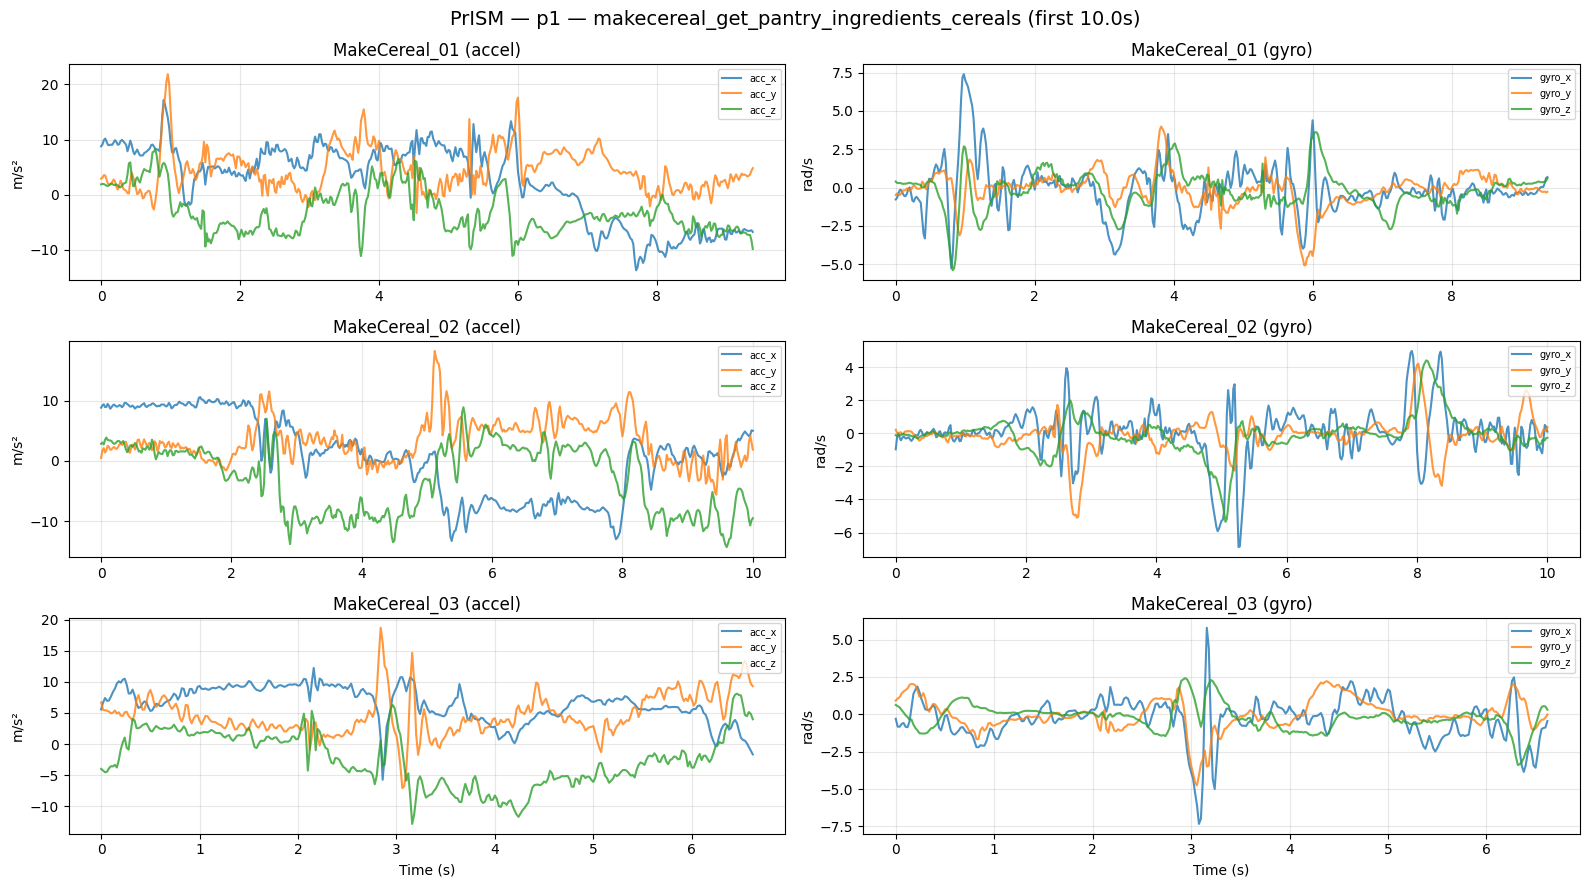

In [9]:
# ============================
# SCRATCH — Quick plot: pick a subject + activity label
# ============================
import matplotlib.pyplot as plt

# ---- CONFIG: change these ----
PLOT_SUBJECT  = "p1"
PLOT_LABEL    = "makecereal_get_pantry_ingredients_cereals"   # dataset_activity_label (canonicalized)
MAX_SECONDS   = 10.0
# ------------------------------

MAX_NS = int(MAX_SECONDS * 1e9)

sub = prism_df[
    (prism_df["subject_id"] == PLOT_SUBJECT) &
    (prism_df["dataset_activity_label"] == PLOT_LABEL)
].copy()

sessions = sub["session_id"].unique()
print(f"Subject {PLOT_SUBJECT}, label '{PLOT_LABEL}': {len(sessions)} sessions")

show = sessions[:6]
if len(show) == 0:
    print("No data found — check PLOT_SUBJECT / PLOT_LABEL")
else:
    fig, axes = plt.subplots(len(show), 2, figsize=(16, 3 * len(show)), sharex=False)
    if len(show) == 1:
        axes = axes[np.newaxis, :]

    for i, sess in enumerate(show):
        chunk = sub[sub["session_id"] == sess]
        t0 = chunk["timestamp_ns"].iloc[0]
        chunk = chunk[(chunk["timestamp_ns"] - t0) <= MAX_NS]
        t_s = (chunk["timestamp_ns"].to_numpy() - t0) / 1e9

        ax = axes[i, 0]
        ax.plot(t_s, chunk["acc_x"], label="acc_x", alpha=0.8)
        ax.plot(t_s, chunk["acc_y"], label="acc_y", alpha=0.8)
        ax.plot(t_s, chunk["acc_z"], label="acc_z", alpha=0.8)
        ax.set_ylabel("m/s²")
        ax.set_title(f"{sess} (accel)")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(True, alpha=0.3)

        ax = axes[i, 1]
        ax.plot(t_s, chunk["gyro_x"], label="gyro_x", alpha=0.8)
        ax.plot(t_s, chunk["gyro_y"], label="gyro_y", alpha=0.8)
        ax.plot(t_s, chunk["gyro_z"], label="gyro_z", alpha=0.8)
        ax.set_ylabel("rad/s")
        ax.set_title(f"{sess} (gyro)")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(True, alpha=0.3)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    fig.suptitle(f"PrISM — {PLOT_SUBJECT} — {PLOT_LABEL} (first {MAX_SECONDS}s)", fontsize=14)
    fig.tight_layout()
    plt.show()